# Analysis of fission yield sampling using SANDY

This document explains step‑by‑step how to:

- load fission‑yield data,
- generate perturbed samples
- analyze correlations
- compute mass yields
- compare uncertainty with/without covariance.

# Processing using API

## Load Libraries and Get FY Data

In [1]:
import sandy
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import pandas as pd

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


We load:

- `sandy` → nuclear data processing and sampling
- `seaborn` / `matplotlib` → visualization
- `pandas` → data handling

## Read U‑235 Fission Yields from JEFF‑4.0

In [2]:
tape = sandy.get_endf6_file("jeff_40", "nfpy", 922350)
fy = sandy.Fy.from_endf6(tape)
fy

       MAT   MT     ZAM     ZAP             E            FY           DFY
0     9228  454  922350   10010  2.530000e-02  1.710000e-05  2.950000e-06
1     9228  454  922350   10020  2.530000e-02  8.400000e-06  2.440000e-06
2     9228  454  922350   10030  2.530000e-02  1.080000e-04  5.860000e-06
3     9228  454  922350   20030  2.530000e-02  1.000000e-14  1.000000e-14
4     9228  454  922350   20040  2.530000e-02  1.700000e-03  8.140000e-05
...    ...  ...     ...     ...           ...           ...           ...
6249  9228  459  922350  771940  1.400000e+07  3.316300e-12  3.446800e-12
6250  9228  459  922350  771950  1.400000e+07  1.405700e-12  1.490400e-12
6251  9228  459  922350  771951  1.400000e+07  1.353800e-12  1.510600e-12
6252  9228  459  922350  781940  1.400000e+07  3.316300e-12  3.446800e-12
6253  9228  459  922350  781950  1.400000e+07  2.691800e-12  2.639300e-12

[6254 rows x 7 columns]

This loads data grouped by:

 - `MT`: 454=independent yields, 459=cumulative yields
 - `ZAM`: fissioning nuclide
 - `E`: fission energy → 0.0253 eV (thermal), 400 keV (fast), 14 MeV (high-energy)


In [3]:
fy.data.E.unique()

array([2.53e-02, 4.00e+05, 1.40e+07])

 - `ZAP`: fission product ID
 - `FY`: best estimate
 - `DFY`: uncertainty

## Generate perturbation coefficients (No Correlation)

In [4]:
smp_size = 1000
smps = tape.get_perturbations(smp_size, write=False, verbose=True)

########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | no explicit seed provided
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | using diagonal matrix (only variance)
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | covariance matrix size=(983, 983)
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | sampling with SMP size=1000 via sampling(seed=106580075637023505068898733920445103389, {})
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | no explicit seed provided
get_perturbations_fy | ZAM=922350 | E=4.00000

Extract only the **thermal FY** sample matrix:

In [5]:
thermal_data = smps["IFY"].data.query("E==0.0253").droplevel(["ZAM", "E"])
thermal_data

SMP,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
ZAP,,,,,,,,,,,,,,,,,,,,,
10010,1.057280,0.960356,0.968090,1.023911,0.936696,0.851884,0.904967,0.859789,0.929558,1.058407,...,0.913319,1.104951,1.000024,1.075887,0.885787,1.113499,1.105293,1.014568,0.775468,1.060353
10020,0.792159,1.624693,1.416676,0.580485,0.900118,0.700702,0.877920,0.772985,1.189581,1.075866,...,0.768049,0.702079,0.943286,1.200076,0.585637,1.353465,0.997981,0.660017,1.058576,1.428682
10030,0.925362,1.061247,1.010230,1.045130,1.024663,1.020542,1.008645,0.981474,0.958687,1.035777,...,0.961014,1.060606,1.014856,0.971633,1.031866,1.151714,0.977237,0.988901,0.971716,1.004162
20030,0.398059,1.514519,0.616399,0.860691,1.038228,0.417859,1.368795,1.202638,0.514759,0.603916,...,0.166718,2.610551,0.579557,0.262041,0.915297,0.736038,1.853470,0.793408,1.550525,3.643679
20040,1.019784,0.996895,0.993700,0.972756,1.034609,1.042402,1.001703,0.988387,1.003662,0.965700,...,1.050709,1.009688,0.995287,0.898072,0.976168,0.972740,1.038543,1.029011,0.997069,0.931256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701770,0.162266,0.411348,0.613457,0.539125,0.794630,0.487693,0.181142,0.603191,0.451244,0.832608,...,0.316971,0.306544,0.547773,0.581008,0.496591,1.084928,1.414170,0.966018,0.515153,0.893775
701771,1.857654,0.724576,0.423175,0.186341,0.844230,0.280067,2.714219,0.102378,0.258686,0.222869,...,2.214910,0.567690,0.505432,0.676523,0.837619,5.283805,0.605617,0.477212,1.782039,0.345983
711750,2.928918,0.933277,1.409109,1.797226,0.187583,1.003077,3.552900,0.974369,0.500681,0.493165,...,0.398001,1.318845,3.868222,0.465649,0.343375,1.549163,0.968697,1.134099,0.638970,0.475969


Plot the correlation matrix.

> Remember: sampling without correlation!

<Axes: xlabel='ZAP', ylabel='ZAP'>

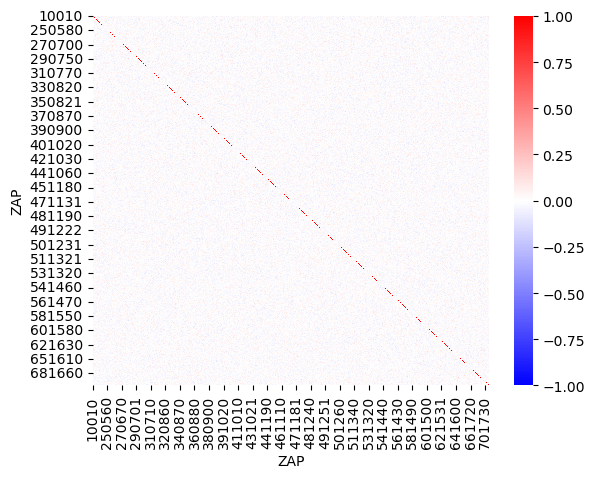

In [6]:
corr = thermal_data.T.corr()
sns.heatmap(corr, cmap="bwr", vmin=-1, vmax=1)

This shows the correlation between fission product yields when samples do not include FY covariance.

## Generate perturbation coefficients (With Correlations)

This only works for JEFF-4.0.

In [7]:
smp_size = 1000
smps_cov = tape.get_perturbations(smp_size, covariance=True, write=False, verbose=True)
thermal_data_cov = smps_cov["IFY"].data.query("E==0.0253").droplevel(["ZAM", "E"])

########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | no explicit seed provided
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | using JEFF-4.0 covariance matrix (with correlations) and fission yield data
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | covariance matrix size=(983, 983)
get_perturbations_fy | ZAM=922350 | E=2.530000E-02 | sampling with SMP size=1000 via sampling(seed=325791257393770108982287302674280612913, {})
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | processing IFY block
get_perturbations_fy | ZAM=922350 | E=4.000000E+05 | no explicit seed provided
get_per

In [8]:
corr_cov = thermal_data_cov.T.corr()

Plot the correlation matrix. This time the samples are correlated!

Text(0.5, 1.0, 'correlated')

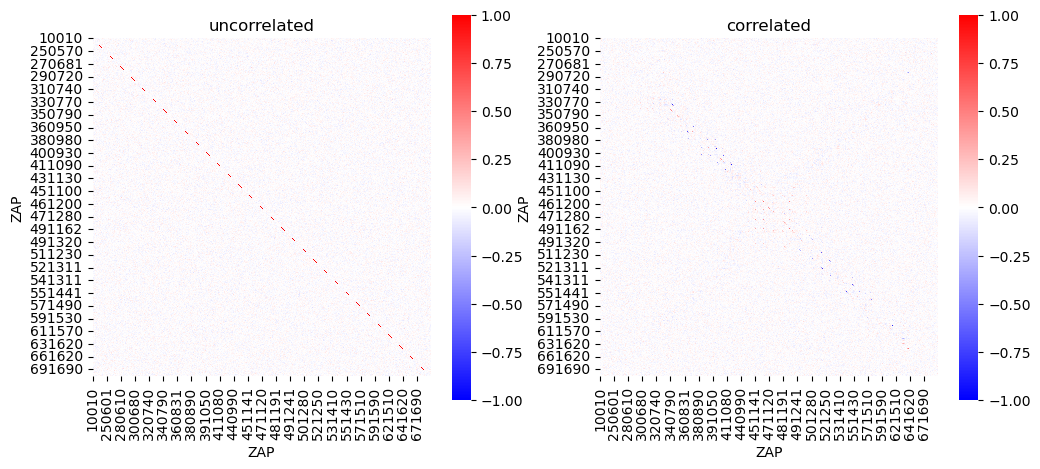

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

with_cov = corr
without_cov = corr_cov

# ZOOMED
# with_cov = corr.iloc[400:500, 400:500]
# without_cov = corr_cov.iloc[400:500, 400:500]

sns.heatmap(with_cov, cmap="bwr", vmin=-1, vmax=1, ax=axs[0], square=True)
sns.heatmap(without_cov, cmap="bwr", vmin=-1, vmax=1, ax=axs[1], square=True)
axs[0].set_title("uncorrelated")
axs[1].set_title("correlated")

Correlations are available for JEFF-4.0 only, and for the thermal fissioning systems of:

    - U-233
    - U-235
    - Pu-239
    - Pu-241

# Run Sampling from Command-Line Arguments

This is identical to what you would run from command line, like:

```bash
python -m sandy.sampling U235_fy.jeff40 --samples 20 --processes 1
```

In [10]:
command_line = "U235_fy.jeff40 --samples 20 --processes 1"

In [11]:
inp = command_line.split()
inp

['U235_fy.jeff40', '--samples', '20', '--processes', '1']

In [12]:
sandy.sampling.run(inp)


========= SAMPLING CONFIGURATION =========
{ 'acer': False,
  'cov_energy_grid': 'csewg239',
  'file': 'U235_fy.jeff40',
  'from_perturbations': False,
  'fycov': False,
  'loglevel': 'info',
  'mf': [31, 33, 35],
  'mt33': 'all',
  'njoy': None,
  'no_verbose': False,
  'only_perturbations': False,
  'processes': 1,
  'samples': 20,
  'seed31': None,
  'seed33': None,
  'seed34': None,
  'seed35': None,
  'show_njoy': False,
  'temperatures': None,
  'tqdm': False}

sampling | processing file: 'U235_fy.jeff40'
sampling | ENDF-6 content: 1 MAT, 2 MF, 3 MT
sampling | detected MF=8/MT=454 (decay): using fission-yield path
########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.5300

Twenty perturbed fission yield files were created.

In [13]:
glob.glob("fy*")

['fy_0',
 'fy_1',
 'fy_10',
 'fy_11',
 'fy_12',
 'fy_13',
 'fy_14',
 'fy_15',
 'fy_16',
 'fy_17',
 'fy_18',
 'fy_19',
 'fy_2',
 'fy_3',
 'fy_4',
 'fy_5',
 'fy_6',
 'fy_7',
 'fy_8',
 'fy_9',
 'fy_sample_analysis-Copy1.ipynb',
 'fy_sample_analysis.ipynb']

Let's inspect the content of the first file.

In [14]:
tape = sandy.Endf6.from_file("fy_0")
fy = sandy.Fy.from_endf6(tape)

print(f"""
FILE CONTENT:
{tape}

FY CONTENT:
{fy}
""")


FILE CONTENT:
MAT   MF  MT 
9228  1   451     9.223500+4 2.330250+2         -1          1  ...
      8   454     92235.0000 4.33020000          3          0  ...
          459     92235.0000 4.33020000          3          0  ...
dtype: object

FY CONTENT:
       MAT   MT     ZAM     ZAP             E            FY           DFY
0     9228  454  922350   10010  2.530000e-02  1.430632e-05  2.950000e-06
1     9228  454  922350   10020  2.530000e-02  6.945288e-06  2.440000e-06
2     9228  454  922350   10030  2.530000e-02  9.973524e-05  5.860000e-06
3     9228  454  922350   20030  2.530000e-02  5.786910e-15  1.000000e-14
4     9228  454  922350   20040  2.530000e-02  1.894199e-03  8.140000e-05
...    ...  ...     ...     ...           ...           ...           ...
6249  9228  459  922350  771940  1.400000e+07  3.316300e-12  3.446800e-12
6250  9228  459  922350  771950  1.400000e+07  1.405700e-12  1.490400e-12
6251  9228  459  922350  771951  1.400000e+07  1.353800e-12  1.510600e-12
625

For each sample of fission yields, let's calculate the so-called mass yields:

$Y(A) = \sum_{Z,M} Y(A, Z, M)$

summing all fission‑product yields for a given mass number A.

In [15]:
mass_yields = fy.get_mass_yield(922350, 0.0253)
mass_yields

A
1      1.430632e-05
2      6.945288e-06
3      9.973524e-05
4      1.894199e-03
6      2.073371e-05
           ...     
173    9.379320e-12
174    1.223901e-12
175    1.126601e-11
176    4.304067e-12
177    6.195563e-13
Name: mass yield, Length: 134, dtype: float64

This is the common plot for fission yields!

<Axes: xlabel='A', ylabel='MASS YIELD'>

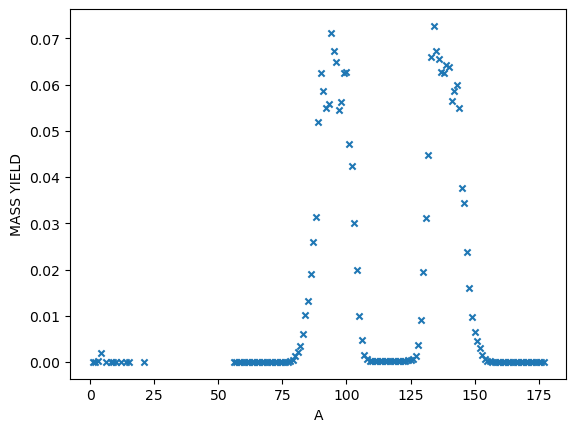

In [16]:
mass_yields.rename("MASS YIELD").reset_index().plot.scatter(x="A", y="MASS YIELD", marker="x")

Let's put it in a loop and show the variability across samples in the graph.

Each color is one FY sample.

In [17]:
data = {}
for i in range(20):
    tape = sandy.Endf6.from_file(f"fy_{i}")
    fy = sandy.Fy.from_endf6(tape)
    data[i] = fy

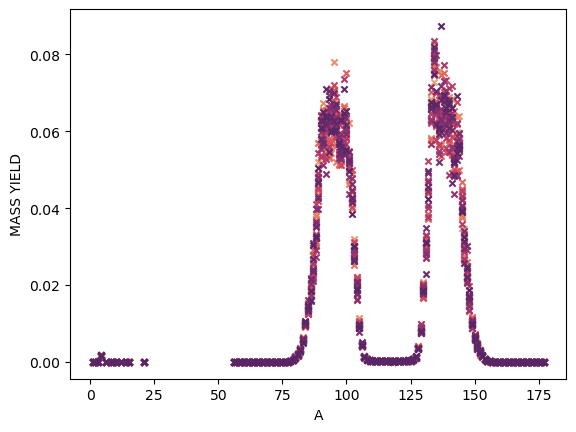

In [24]:
fig, ax = plt.subplots()

colors = sns.color_palette("flare", n_colors=len(data))

mass_yields = {}
for i, fy in data.items():
    mass_yields[i] = fy.get_mass_yield(922350, 0.0253)
    mass_yields[i].rename("MASS YIELD").reset_index().plot.scatter(x="A", y="MASS YIELD", marker="x", color=colors[i], ax=ax)

mass_yields = pd.DataFrame(mass_yields)

Calculate and plot the sample standard deviation.

<Axes: xlabel='A'>

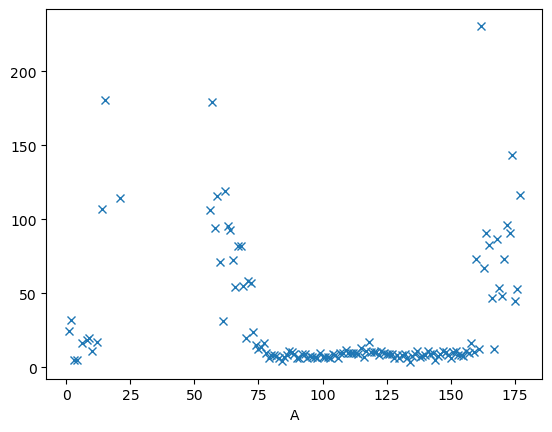

In [25]:
fig, ax = plt.subplots()

(mass_yields.std(axis=1) / mass_yields.mean(axis=1) * 100).plot(ls="none", marker="x", ax=ax)

#ax.set(ylabel="standard deviation / %")

# Run Sampling from Command-Line Arguments, enabling covariances

For JEFF-4.0, the command line option `--fycov` allows sampling fission yields with covariance data for U-233, U-235, Pu-239 and Pu-241.

This works for thermal fissioning systems only.

Lets'run it!

> Watch out: the previous files are overwritten! If you still want them, move them or rename them.

In [27]:
sandy.sampling.run("U235_fy.jeff40 --samples 20 --processes 1 --fycov".split())


========= SAMPLING CONFIGURATION =========
{ 'acer': False,
  'cov_energy_grid': 'csewg239',
  'file': 'U235_fy.jeff40',
  'from_perturbations': False,
  'fycov': True,
  'loglevel': 'info',
  'mf': [31, 33, 35],
  'mt33': 'all',
  'njoy': None,
  'no_verbose': False,
  'only_perturbations': False,
  'processes': 1,
  'samples': 20,
  'seed31': None,
  'seed33': None,
  'seed34': None,
  'seed35': None,
  'show_njoy': False,
  'temperatures': None,
  'tqdm': False}

sampling | processing file: 'U235_fy.jeff40'
sampling | ENDF-6 content: 1 MAT, 2 MF, 3 MT
sampling | detected MF=8/MT=454 (decay): using fission-yield path
########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | ZAM=922350 | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf6 | reading ZAM=922350 kind=CFY
get_perturbations_fy | ZAM=922350 | E=2.53000

Let's get again the mass yields.

In [28]:
data = {}
for i in range(20):
    tape = sandy.Endf6.from_file(f"fy_{i}")
    fy = sandy.Fy.from_endf6(tape)
    data[i] = fy.get_mass_yield(922350, 0.0253)

mass_yields_cov = pd.DataFrame(data)

...and now compare the uncertainties.

[Text(0, 0.5, 'standard deviation / %')]

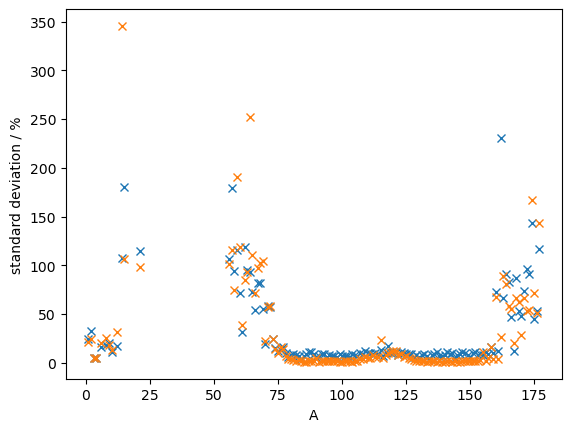

In [29]:
fig, ax = plt.subplots()

(mass_yields.std(axis=1) / mass_yields.mean(axis=1) * 100).plot(ls="none", marker="x", ax=ax)
(mass_yields_cov.std(axis=1) / mass_yields_cov.mean(axis=1) * 100).plot(ls="none", marker="x", ax=ax)

ax.set(ylabel="standard deviation / %")